In [17]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from imblearn.over_sampling import SMOTE

In [18]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_smote.csv"

TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled.csv"
SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote.csv"

USE_FE = False

In [19]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...
31444,0.232582,0.301550,2.55280,1.074847,84.6528,30.2489,243.604,125.6900,Sharp Water Increase (Circuit),7.0
31445,0.234111,0.298961,2.67178,1.074847,85.2649,30.1380,232.345,128.3120,Sharp Water Increase (Circuit),7.0
31446,0.231709,0.301727,2.64041,1.730701,84.5624,30.0042,234.070,129.3120,Sharp Water Increase (Circuit),7.0
31447,0.233409,0.303753,2.08954,1.074847,84.6937,30.1634,236.700,130.0000,Sharp Water Increase (Circuit),7.0


In [20]:
smote = SMOTE(random_state=SEED)
X_res_smote, y_res_smote = smote.fit_resample(dataframe_train.drop(columns=["anomaly", "description"]), dataframe_train.anomaly.values)

X_res_smote.shape, y_res_smote.shape

((315196, 8), (315196,))

In [21]:
dataframe_train_smote = pd.DataFrame(X_res_smote, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)
dataframe_train_smote["anomaly"] = y_res_smote

dataframe_train_smote

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,0.219595,0.267058,2.972050,1.074847,88.916600,28.931900,227.339000,127.000000,0.0
1,0.028225,0.042124,1.432100,1.401284,68.646200,24.764000,245.677000,32.980500,0.0
2,0.214053,0.259569,2.228980,1.730701,88.278700,29.679000,227.822000,127.000000,0.0
3,0.255422,0.294430,2.998710,1.074847,86.207300,28.812600,232.379000,126.000000,0.0
4,0.081667,0.129274,1.561180,0.733489,87.240700,22.135800,234.136000,77.000000,0.0
...,...,...,...,...,...,...,...,...,...
315191,0.027347,0.040987,1.171474,0.676276,70.143791,24.332521,236.785816,31.963400,13.0
315192,0.027507,0.040421,0.864235,1.073357,69.298759,24.106630,231.858575,28.956800,13.0
315193,0.027503,0.038595,0.982861,1.114231,68.557498,24.251648,228.487008,28.965949,13.0
315194,0.027500,0.040265,0.693626,1.073357,68.661079,24.164090,237.719017,31.623808,13.0


In [22]:
print("\nDataset after SMOTE:")
print(f"Total samples: {len(y_res_smote)}")
unique, counts = np.unique(y_res_smote, return_counts=True)
print(f"Class distribution: {dict(zip(unique, counts))}")


Dataset after SMOTE:
Total samples: 315196
Class distribution: {np.float64(0.0): np.int64(22514), np.float64(1.0): np.int64(22514), np.float64(2.0): np.int64(22514), np.float64(3.0): np.int64(22514), np.float64(4.0): np.int64(22514), np.float64(5.0): np.int64(22514), np.float64(6.0): np.int64(22514), np.float64(7.0): np.int64(22514), np.float64(8.0): np.int64(22514), np.float64(9.0): np.int64(22514), np.float64(10.0): np.int64(22514), np.float64(11.0): np.int64(22514), np.float64(12.0): np.int64(22514), np.float64(13.0): np.int64(22514)}


In [23]:
columns = dataframe_train.drop(columns=["anomaly", "description"]).columns
for idx, col in enumerate(columns):
    print(f"{idx}: {col}")

0: Accelerometer1RMS
1: Accelerometer2RMS
2: Current
3: Pressure
4: Temperature
5: Thermocouple
6: Voltage
7: Volume Flow RateRMS


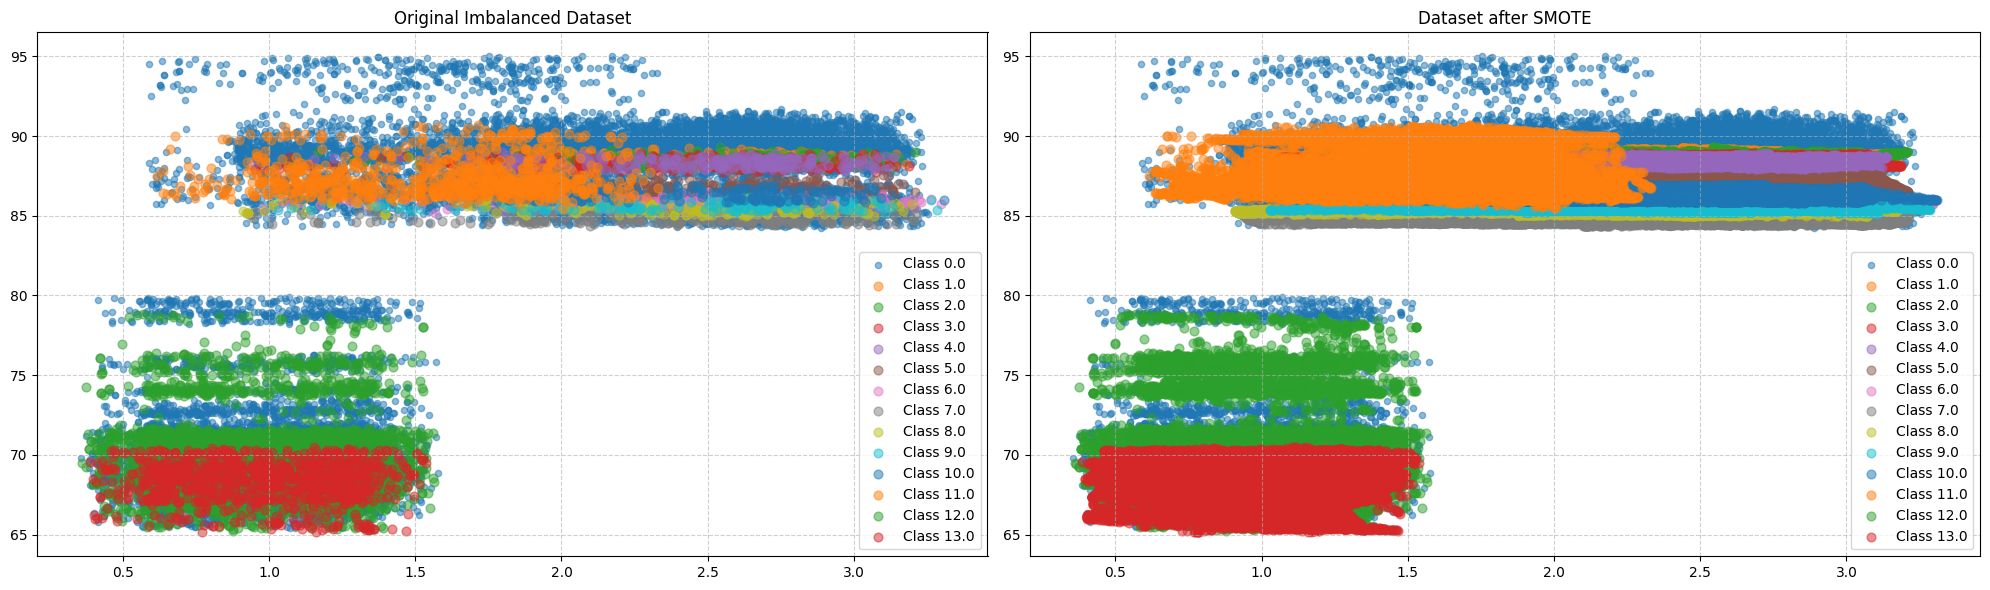

In [24]:
col1, col2 = columns[2], columns[4]

fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=PLOT_DPI)

axs[0].set_title("Original Imbalanced Dataset")
for class_label in np.unique(dataframe_train.anomaly):
    axs[0].scatter(
                    dataframe_train[dataframe_train.anomaly == class_label][col1], 
                    dataframe_train[dataframe_train.anomaly == class_label][col2], 
                    label=f'Class {class_label}', alpha=0.5, s=20 if class_label == 0 else 40
    )
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].set_title("Dataset after SMOTE")
for class_label in np.unique(dataframe_train_smote.anomaly):
    axs[1].scatter(
                    dataframe_train_smote[dataframe_train_smote.anomaly == class_label][col1], 
                    dataframe_train_smote[dataframe_train_smote.anomaly == class_label][col2], 
                    label=f'Class {class_label}', alpha=0.5, s=20 if class_label == 0 else 40
    )
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [25]:
dataframe_train_smote.shape

(315196, 9)

In [26]:
dataframe_train_smote.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,0.0


In [27]:
anomaly_ids = dict()
for idx, desc in zip(dataframe_train.anomaly, dataframe_train.description):
    anomaly_ids[idx] = desc


for idx, desc in anomaly_ids.items():
    print(f"{idx}: {desc}")

0.0: No Anomaly
12.0: Inlet Valve Malfunction
8.0: Water Drainage (Cavitation)
11.0: Fluid Leaks
13.0: Outlet Valve Malfunction
2.0: Linear - Rotor Imbalance
1.0: Sharp - Rotor Imbalance
5.0: Exponential - Rotor Imbalance
3.0: Step - Rotor Imbalance
6.0: Slow Water Increase (Circuit)
4.0: Dirac - Rotor Imbalance
9.0: Two-phase Supply (Cavitation)
10.0: Water Temperature Increase
7.0: Sharp Water Increase (Circuit)


In [28]:
desc = list()
for idx in dataframe_train_smote.anomaly:
    desc.append(anomaly_ids[idx])

dataframe_train_smote["description"] = desc
dataframe_train_smote

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
0,0.219595,0.267058,2.972050,1.074847,88.916600,28.931900,227.339000,127.000000,0.0,No Anomaly
1,0.028225,0.042124,1.432100,1.401284,68.646200,24.764000,245.677000,32.980500,0.0,No Anomaly
2,0.214053,0.259569,2.228980,1.730701,88.278700,29.679000,227.822000,127.000000,0.0,No Anomaly
3,0.255422,0.294430,2.998710,1.074847,86.207300,28.812600,232.379000,126.000000,0.0,No Anomaly
4,0.081667,0.129274,1.561180,0.733489,87.240700,22.135800,234.136000,77.000000,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
315191,0.027347,0.040987,1.171474,0.676276,70.143791,24.332521,236.785816,31.963400,13.0,Outlet Valve Malfunction
315192,0.027507,0.040421,0.864235,1.073357,69.298759,24.106630,231.858575,28.956800,13.0,Outlet Valve Malfunction
315193,0.027503,0.038595,0.982861,1.114231,68.557498,24.251648,228.487008,28.965949,13.0,Outlet Valve Malfunction
315194,0.027500,0.040265,0.693626,1.073357,68.661079,24.164090,237.719017,31.623808,13.0,Outlet Valve Malfunction


In [29]:
dataframe_train_smote.to_csv(SAVE_DATA_FILE, index=False)